# NB_07B v2 — Backtest de cartera con scores ML corregido


## Motivo de esta versión

La primera versión de NB_07B generó resultados útiles de capital final, número de operaciones, win rate y profit factor, pero el cálculo de `max_drawdown_event` quedó contaminado por un problema en el registro de equity durante cierres múltiples de posiciones.

En esta versión se corrige el cálculo de la curva event-driven:

- se procesan salidas antes que entradas en cada fecha;
- la equity se calcula siempre como `cash + capital asignado a posiciones abiertas`;
- se evita registrar caídas artificiales de equity por excluir posiciones abiertas aún no procesadas;
- se exportan nuevas tablas en `outputs_nb07b_v2/`.

## Pregunta experimental

> Si se usan los scores de modelos supervisados para seleccionar señales dentro de una cartera con capital limitado y máximo de posiciones, ¿mejora el resultado frente al baseline técnico?

In [1]:
# ============================================================
# 0. Imports y configuración
# ============================================================

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

INITIAL_CAPITAL = 200_000.0
MAX_POSITIONS = 20

BASE_DIR = Path.cwd()
PREDICTIONS_PATH = BASE_DIR / "../NB_06/outputs_nb06b/predictions_walkforward_nb06b.csv.zip"
AUDIT_PATH = BASE_DIR / "../NB_05/df_nb04b2_v4_signal_trade_audit.csv"

OUTPUT_DIR = BASE_DIR / "outputs_nb07b_v2"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"
EQUITY_DIR = FIG_DIR / "equity_curves"
DRAWDOWN_DIR = FIG_DIR / "drawdowns"
YEARLY_DIR = FIG_DIR / "yearly"

for d in [OUTPUT_DIR, TABLE_DIR, FIG_DIR, EQUITY_DIR, DRAWDOWN_DIR, YEARLY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("PREDICTIONS_PATH:", PREDICTIONS_PATH, "->", PREDICTIONS_PATH.exists())
print("AUDIT_PATH:", AUDIT_PATH, "->", AUDIT_PATH.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)

if not PREDICTIONS_PATH.exists():
    raise FileNotFoundError(f"No se encuentra {PREDICTIONS_PATH}")
if not AUDIT_PATH.exists():
    raise FileNotFoundError(f"No se encuentra {AUDIT_PATH}")

BASE_DIR: /Users/rbr/TFM_MVP/JUNIO/NB_07
PREDICTIONS_PATH: /Users/rbr/TFM_MVP/JUNIO/NB_07/../NB_06/outputs_nb06b/predictions_walkforward_nb06b.csv.zip -> True
AUDIT_PATH: /Users/rbr/TFM_MVP/JUNIO/NB_07/../NB_05/df_nb04b2_v4_signal_trade_audit.csv -> True
OUTPUT_DIR: /Users/rbr/TFM_MVP/JUNIO/NB_07/outputs_nb07b_v2


## 1. Carga de predicciones y auditoría

Se utilizan:

- `predictions_walkforward_nb06b.csv.zip`: scores y predicciones generadas en NB_06B.
- `df_nb04b2_v4_signal_trade_audit.csv`: auditoría de señales V4, fechas de salida y retornos combo.

In [2]:
# ============================================================
# 1. Carga de datos
# ============================================================

pred = pd.read_csv(PREDICTIONS_PATH)
audit = pd.read_csv(AUDIT_PATH)

audit = audit.rename(columns={
    "Ticker": "ticker",
    "Year": "signal_year",
    "ret_combo": "outcome_ret_combo",
    "ret_core": "outcome_ret_core",
    "ret_tactical": "outcome_ret_tactical",
})

for df in [pred, audit]:
    for col in ["signal_date", "entry_date", "core_exit_date", "tactical_exit_date"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

print("Predicciones:", pred.shape)
print("Auditoría:", audit.shape)
display(pred.head())
display(audit.head())

Predicciones: (13040, 13)
Auditoría: (8155, 38)


,signal_id,ticker,signal_date,entry_date,signal_year,target_combo_positive,outcome_ret_combo,fold,model,score,pred_fixed_0_50,threshold_optimized_f1,pred_optimized_f1
0,4896,AMT,2023-01-03,2023-01-03,2023,1,0.0230,1,Dummy,1.0000,1,0.5000,1
1,4897,A,2023-01-04,2023-01-04,2023,0,-0.0018,1,Dummy,1.0000,1,0.5000,1
2,4898,ABT,2023-01-04,2023-01-04,2023,0,-0.0310,1,Dummy,1.0000,1,0.5000,1
3,4899,ADI,2023-01-04,2023-01-04,2023,1,0.1004,1,Dummy,1.0000,1,0.5000,1
4,4900,BDX,2023-01-04,2023-01-04,2023,0,-0.0720,1,Dummy,1.0000,1,0.5000,1


,signal_id,ticker,signal_year,signal_date,entry_date,entry_price,entry_execution_mode,entry_family,tk_confirmation_status,chikou_diagnostic_status,technical_priority_score,kumo_actual_thickness_pct,Volume_Rel,Stoch_K_entry,Stoch_D_entry,tactical_exit_date,tactical_exit_price,tactical_exit_reason,core_exit_date,core_exit_price,core_exit_reason,trailing_activated,trailing_activated_date,first_inside_kumo_date,first_below_kumo_date,first_stoch_bearish_date,first_ha2_bearish_date,outcome_ret_tactical,outcome_ret_core,outcome_ret_combo,mfe,mae,mfe_minus_abs_mae,duration_core_bars,duration_tactical_bars,max_high_until_core_exit,min_low_until_core_exit,negative_diagnosis
0,1,ALLE,2018,2018-04-16,2018-04-16,77.3274,close_signal,v4_kumo_actual_y_futuro_alcista_con_tk_cross,tk_cross_up_recent,chikou_parcial_sobre_close_22ago,11.2500,0.0255,1.0127,70.7483,64.1724,2018-04-26,71.1861,TACTICAL_EXIT_WITH_CORE_INVALIDATION,2018-04-26,71.1861,CORE_CLOSE_BELOW_KUMO_BOTTOM,False,NaN,2018-04-20,2018-04-26,2018-04-19,2018-04-20,-0.0794,-0.0794,-0.0794,0.0196,-0.1156,-0.0961,8,8,78.8400,68.3872,fallo_sin_recorrido_mfe_menor_2pct
1,2,BF-B,2018,2018-04-16,2018-04-16,48.7357,close_signal,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,10.5000,0.0182,1.2991,92.9632,88.9731,2018-05-25,50.3857,TACTICAL_TRAILING_3PCT_stop_intraday,2018-06-06,45.8747,CORE_CLOSE_BELOW_KUMO_BOTTOM,True,2018-05-23,NaN,2018-06-06,2018-04-17,2018-04-19,0.0339,-0.0587,-0.0124,0.0658,-0.0682,-0.0024,36,29,51.9440,45.4113,tuvo_mfe_5pct_y_trailing_pero_combo_negativo
2,3,PGR,2018,2018-04-16,2018-04-16,48.0361,close_signal,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,no_tk_confirmation_yet,chikou_no_confirmado_o_sin_historia,8.7500,0.0311,1.4822,62.8572,47.5003,2018-06-18,48.8087,TACTICAL_TRAILING_3PCT_gap_open_below_stop,2018-06-25,47.4448,CORE_CLOSE_BELOW_KUMO_BOTTOM,True,2018-06-18,2018-04-25,2018-06-25,2018-04-18,2018-04-20,0.0161,-0.0123,0.0019,0.0630,-0.0463,0.0167,49,44,51.0635,45.8129,positive_or_flat
3,4,TECH,2018,2018-04-16,2018-04-16,35.9652,close_signal,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,no_tk_confirmation_yet,chikou_libre_sobre_precio_y_kumo_22ago,9.7500,0.0305,1.0450,78.7651,72.5172,2018-06-21,38.8970,TACTICAL_TRAILING_3PCT_stop_intraday,2018-06-27,35.1287,CORE_CLOSE_BELOW_KUMO_BOTTOM,True,2018-06-21,2018-05-03,2018-06-27,2018-04-19,2018-04-30,0.0815,-0.0233,0.0291,0.1150,-0.0430,0.0720,51,47,40.1000,34.4204,positive_or_flat
4,5,TKO,2018,2018-04-16,2018-04-16,35.8697,close_signal,v4_kumo_actual_y_futuro_alcista_con_tk_cross,tk_cross_up_recent,chikou_libre_sobre_precio_y_kumo_22ago,11.5000,0.0604,1.4770,98.3573,92.1879,2018-08-08,72.0430,TACTICAL_EXIT_AT_CORE_OR_MAX_HOLD,2018-08-08,72.0430,MAX_HOLD_OR_DATA_END,False,NaN,NaN,NaN,2018-04-17,2018-06-01,1.0085,1.0085,1.0085,1.1808,-0.0304,1.1504,80,80,78.2242,34.7794,positive_or_flat


## 2. Preparación de señales para backtest

Se consolida una tabla de señales de test con:

- fecha real de entrada;
- fecha auditada de salida;
- retorno combo auditado;
- variables auxiliares para priorización técnica.

In [3]:
# ============================================================
# 2. Preparación de señales
# ============================================================

required_pred_cols = [
    "signal_id", "ticker", "signal_date", "entry_date", "signal_year",
    "target_combo_positive", "outcome_ret_combo", "fold", "model", "score",
    "pred_fixed_0_50", "threshold_optimized_f1", "pred_optimized_f1"
]
missing = [c for c in required_pred_cols if c not in pred.columns]
if missing:
    raise ValueError(f"Faltan columnas en predicciones: {missing}")

audit_cols = [
    "signal_id", "ticker", "entry_date", "entry_price",
    "core_exit_date", "tactical_exit_date",
    "outcome_ret_combo", "outcome_ret_core", "outcome_ret_tactical",
    "mfe", "mae", "duration_core_bars", "entry_family",
    "tk_confirmation_status", "chikou_diagnostic_status",
    "technical_priority_score", "kumo_actual_thickness_pct", "Volume_Rel",
    "Stoch_K_entry", "Stoch_D_entry"
]
audit_cols = [c for c in audit_cols if c in audit.columns]

test_signals = pred[["signal_id", "ticker", "signal_date", "entry_date", "signal_year", "target_combo_positive"]].drop_duplicates()

signals = test_signals.merge(
    audit[audit_cols],
    on=["signal_id", "ticker", "entry_date"],
    how="left",
    suffixes=("", "_audit")
)

signals["ret_combo_for_backtest"] = pd.to_numeric(signals["outcome_ret_combo"], errors="coerce")
signals["exit_date"] = pd.to_datetime(signals["core_exit_date"], errors="coerce")

if "duration_core_bars" in signals.columns:
    fallback_exit = signals["entry_date"] + pd.to_timedelta(signals["duration_core_bars"].fillna(20).clip(lower=1).astype(int), unit="D")
else:
    fallback_exit = signals["entry_date"] + pd.to_timedelta(20, unit="D")

signals["exit_date"] = signals["exit_date"].fillna(fallback_exit)
signals = signals.dropna(subset=["entry_date", "exit_date", "ret_combo_for_backtest"])

bad_dates = signals["exit_date"] < signals["entry_date"]
if bad_dates.any():
    print(f"Advertencia: {bad_dates.sum()} exit_date anteriores a entry_date. Se corrigen a entry_date.")
    signals.loc[bad_dates, "exit_date"] = signals.loc[bad_dates, "entry_date"]

print("Señales únicas de test:", signals.shape)
print("Años:", sorted(signals["signal_year"].unique()))
display(signals.head())

Señales únicas de test: (3260, 25)
Años: [2023, 2024, 2025]


,signal_id,ticker,signal_date,entry_date,signal_year,target_combo_positive,entry_price,core_exit_date,tactical_exit_date,outcome_ret_combo,outcome_ret_core,outcome_ret_tactical,mfe,mae,duration_core_bars,entry_family,tk_confirmation_status,chikou_diagnostic_status,technical_priority_score,kumo_actual_thickness_pct,Volume_Rel,Stoch_K_entry,Stoch_D_entry,ret_combo_for_backtest,exit_date
0,4896,AMT,2023-01-03,2023-01-03,2023,1,192.0667,2023-02-14,2023-01-19,0.0230,0.0022,0.0438,0.0974,-0.0174,29,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,no_tk_confirmation_yet,chikou_no_confirmado_o_sin_historia,8.7500,0.0598,1.0287,47.2669,44.6361,0.0230,2023-02-14
1,4897,A,2023-01-04,2023-01-04,2023,0,148.0064,2023-02-16,2023-01-30,-0.0018,-0.0224,0.0187,0.0522,-0.0571,30,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,no_tk_confirmation_yet,chikou_no_confirmado_o_sin_historia,8.7500,0.0616,1.0282,47.8994,35.3844,-0.0018,2023-02-16
2,4898,ABT,2023-01-04,2023-01-04,2023,0,103.7283,2023-02-15,2023-02-15,-0.0310,-0.0310,-0.0310,0.0403,-0.0400,29,v4_kumo_actual_y_futuro_alcista_con_tk_cross,tk_cross_up_recent,chikou_libre_sobre_precio_y_kumo_22ago,11.7500,0.0263,1.0255,76.6805,62.7344,-0.0310,2023-02-15
3,4899,ADI,2023-01-04,2023-01-04,2023,1,157.0048,2023-04-27,2023-02-22,0.1004,0.0756,0.1252,0.2005,-0.0382,78,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,no_tk_confirmation_yet,chikou_no_confirmado_o_sin_historia,8.7500,0.0499,1.1655,34.8422,22.2726,0.1004,2023-04-27
4,4900,BDX,2023-01-04,2023-01-04,2023,0,191.1648,2023-02-21,2023-02-21,-0.0720,-0.0720,-0.0720,0.0072,-0.0852,32,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,10.7500,0.0166,1.2312,71.2576,63.3223,-0.0720,2023-02-21


## 3. Definición de estrategias

Se replican las estrategias del NB_07:

- baseline técnico;
- Top 10/20/30 por score Random Forest;
- Top 10/20/30 por score XGBoost;
- Logistic Regression Top 10;
- thresholds fijos;
- thresholds optimizados por F1.

In [4]:
# ============================================================
# 3. Estrategias de selección
# ============================================================

def select_top_pct(pred_df, model_name, pct):
    sub = pred_df[pred_df["model"] == model_name].copy()
    parts = []
    for fold, g in sub.groupby("fold"):
        n = max(1, int(np.ceil(len(g) * pct)))
        parts.append(g.sort_values("score", ascending=False).head(n))
    out = pd.concat(parts, ignore_index=True)
    out["strategy"] = f"{model_name}_TOP_{int(pct*100)}"
    out["selection_score"] = out["score"]
    return out

def select_threshold_fixed(pred_df, model_name, threshold=0.50):
    sub = pred_df[(pred_df["model"] == model_name) & (pred_df["score"] >= threshold)].copy()
    sub["strategy"] = f"{model_name}_THRESHOLD_0_50"
    sub["selection_score"] = sub["score"]
    return sub

def select_threshold_opt(pred_df, model_name):
    sub = pred_df[(pred_df["model"] == model_name) & (pred_df["pred_optimized_f1"] == 1)].copy()
    sub["strategy"] = f"{model_name}_THRESHOLD_OPT_F1"
    sub["selection_score"] = sub["score"]
    return sub

strategies = []

baseline = pred[["signal_id", "fold"]].drop_duplicates().copy()
baseline["strategy"] = "BASELINE_TECNICO_ALL"
baseline["model"] = "TechnicalBaseline"
baseline["score"] = np.nan
baseline["selection_score"] = np.nan
strategies.append(baseline)

for model_name in ["RandomForest", "XGBoost"]:
    for pct in [0.10, 0.20, 0.30]:
        strategies.append(select_top_pct(pred, model_name, pct))

strategies.append(select_top_pct(pred, "LogisticRegression", 0.10))

for model_name in ["RandomForest", "XGBoost", "LogisticRegression"]:
    strategies.append(select_threshold_fixed(pred, model_name, 0.50))
    strategies.append(select_threshold_opt(pred, model_name))

strategy_signals = pd.concat(strategies, ignore_index=True)
strategy_signals = strategy_signals.sort_values(["strategy", "signal_id"]).drop_duplicates(["strategy", "signal_id"])

bt_candidates = strategy_signals[["strategy", "model", "signal_id", "selection_score"]].merge(
    signals,
    on="signal_id",
    how="left"
)
bt_candidates = bt_candidates.dropna(subset=["entry_date", "exit_date", "ret_combo_for_backtest"])

display(bt_candidates.groupby("strategy")["signal_id"].nunique().sort_values(ascending=False).to_frame("selected_signals"))

,selected_signals
strategy,
BASELINE_TECNICO_ALL,3260
XGBoost_THRESHOLD_OPT_F1,3254
RandomForest_THRESHOLD_OPT_F1,3244
LogisticRegression_THRESHOLD_OPT_F1,2609
RandomForest_THRESHOLD_0_50,2350
XGBoost_THRESHOLD_0_50,1836
LogisticRegression_THRESHOLD_0_50,1613
RandomForest_TOP_30,980
XGBoost_TOP_30,980


## 4. Simulador event-driven corregido

Correcciones frente a NB_07B v1:

1. En cada fecha se procesan primero las salidas y luego las entradas.
2. La equity se registra siempre como `cash + sum(allocation de posiciones abiertas)`.
3. El drawdown event-driven ya no debería mostrar caídas artificiales cercanas al -95%.

In [5]:
# ============================================================
# 4. Simulador corregido
# ============================================================

def profit_factor_from_pnl(pnls):
    pnls = pd.Series(pnls).dropna()
    gains = pnls[pnls > 0].sum()
    losses = -pnls[pnls < 0].sum()
    if losses == 0:
        return np.inf if gains > 0 else np.nan
    return gains / losses

def max_drawdown_from_equity(equity):
    s = pd.Series(equity).astype(float)
    if s.empty:
        return np.nan
    return (s / s.cummax() - 1).min()

def simulate_strategy_v2(candidates, strategy_name, initial_capital=200_000.0, max_positions=20):
    df = candidates[candidates["strategy"] == strategy_name].copy()
    if df.empty:
        return None, pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    if "technical_priority_score" not in df.columns:
        df["technical_priority_score"] = 0

    df["priority_score"] = df["selection_score"].fillna(df["technical_priority_score"]).fillna(0)
    df = df.sort_values(["entry_date", "priority_score", "signal_id"], ascending=[True, False, True]).reset_index(drop=True)

    cash = initial_capital
    open_positions = {}
    trade_log = []
    skipped_log = []
    equity_records = []

    # Agrupar señales por fecha de entrada
    all_entry_dates = sorted(df["entry_date"].dropna().unique())

    def current_equity():
        return cash + sum(pos["allocation"] for pos in open_positions.values())

    def record(date, event, signal_id=None):
        equity_records.append({
            "date": pd.to_datetime(date),
            "equity": current_equity(),
            "cash": cash,
            "open_alloc": sum(pos["allocation"] for pos in open_positions.values()),
            "n_open": len(open_positions),
            "event": event,
            "signal_id": signal_id,
            "strategy": strategy_name
        })

    record(df["entry_date"].min(), "init", None)

    # Procesar fechas de entrada y, antes de cada entrada, salidas vencidas
    for entry_date in all_entry_dates:
        entry_date = pd.to_datetime(entry_date)

        # Cerrar posiciones con salida <= fecha actual
        to_close = [pid for pid, pos in open_positions.items() if pos["exit_date"] <= entry_date]
        for pid in sorted(to_close):
            pos = open_positions.pop(pid)
            pnl = pos["allocation"] * pos["ret"]
            cash += pos["allocation"] + pnl
            pos_out = pos.copy()
            pos_out["pnl"] = pnl
            pos_out["exit_processed_date"] = pos["exit_date"]
            pos_out["cash_after_exit"] = cash
            trade_log.append(pos_out)
            record(pos["exit_date"], "exit", pos["signal_id"])

        # Abrir señales de esta fecha ordenadas por score/prioridad
        day_candidates = df[df["entry_date"] == entry_date].sort_values(["priority_score", "signal_id"], ascending=[False, True])

        for _, row in day_candidates.iterrows():
            if len(open_positions) >= max_positions:
                skipped_log.append({
                    "strategy": strategy_name,
                    "signal_id": row["signal_id"],
                    "ticker": row["ticker"],
                    "entry_date": entry_date,
                    "reason": "max_positions_reached"
                })
                continue

            equity_basis = current_equity()
            allocation = min(cash, equity_basis / max_positions)

            if allocation <= 0:
                skipped_log.append({
                    "strategy": strategy_name,
                    "signal_id": row["signal_id"],
                    "ticker": row["ticker"],
                    "entry_date": entry_date,
                    "reason": "no_cash_available"
                })
                continue

            cash -= allocation
            pid = row["signal_id"]

            open_positions[pid] = {
                "strategy": strategy_name,
                "signal_id": row["signal_id"],
                "ticker": row["ticker"],
                "entry_date": row["entry_date"],
                "exit_date": row["exit_date"],
                "signal_year": row["signal_year"],
                "allocation": allocation,
                "ret": row["ret_combo_for_backtest"],
                "selection_score": row.get("selection_score", np.nan),
                "priority_score": row.get("priority_score", np.nan),
                "entry_family": row.get("entry_family", None),
                "tk_confirmation_status": row.get("tk_confirmation_status", None),
                "chikou_diagnostic_status": row.get("chikou_diagnostic_status", None),
            }
            record(entry_date, "entry", row["signal_id"])

    # Cerrar posiciones remanentes por fecha de salida
    for exit_date in sorted(set(pos["exit_date"] for pos in open_positions.values())):
        to_close = [pid for pid, pos in open_positions.items() if pos["exit_date"] <= exit_date]
        for pid in sorted(to_close):
            pos = open_positions.pop(pid)
            pnl = pos["allocation"] * pos["ret"]
            cash += pos["allocation"] + pnl
            pos_out = pos.copy()
            pos_out["pnl"] = pnl
            pos_out["exit_processed_date"] = pos["exit_date"]
            pos_out["cash_after_exit"] = cash
            trade_log.append(pos_out)
            record(pos["exit_date"], "exit", pos["signal_id"])

    trades = pd.DataFrame(trade_log)
    skipped = pd.DataFrame(skipped_log)
    equity = pd.DataFrame(equity_records).sort_values(["date", "event"]).reset_index(drop=True)

    # Consolidar último valor diario
    equity_daily = equity.groupby("date", as_index=False).agg(
        equity=("equity", "last"),
        cash=("cash", "last"),
        open_alloc=("open_alloc", "last"),
        n_open=("n_open", "last")
    )
    equity_daily["strategy"] = strategy_name

    final_capital = equity_daily["equity"].iloc[-1]
    total_return = final_capital / initial_capital - 1

    start_date = df["entry_date"].min()
    end_date = max(df["exit_date"].max(), df["entry_date"].max())
    years = max((end_date - start_date).days / 365.25, 1/365.25)
    cagr = (final_capital / initial_capital) ** (1 / years) - 1 if final_capital > 0 else np.nan

    pnls = trades["pnl"] if "pnl" in trades.columns else pd.Series(dtype=float)
    rets = trades["ret"] if "ret" in trades.columns else pd.Series(dtype=float)

    metrics = {
        "strategy": strategy_name,
        "selected_signals": int(df["signal_id"].nunique()),
        "entered_trades": int(len(trades)),
        "skipped_signals": int(len(skipped)),
        "initial_capital": initial_capital,
        "final_capital": final_capital,
        "total_return": total_return,
        "cagr_approx": cagr,
        "max_drawdown_event": max_drawdown_from_equity(equity_daily["equity"]),
        "win_rate_trades": (rets > 0).mean() if len(rets) else np.nan,
        "mean_trade_return": rets.mean() if len(rets) else np.nan,
        "median_trade_return": rets.median() if len(rets) else np.nan,
        "profit_factor": profit_factor_from_pnl(pnls),
        "avg_allocation": trades["allocation"].mean() if "allocation" in trades.columns and len(trades) else np.nan,
        "avg_holding_days": ((trades["exit_date"] - trades["entry_date"]).dt.days.mean() if len(trades) else np.nan),
        "period_start": start_date,
        "period_end": end_date,
    }

    return metrics, trades, equity_daily, skipped

## 5. Ejecución de simulaciones

Se ejecutan todas las estrategias. Las tablas se exportan en `outputs_nb07b_v2/`.

In [6]:
# ============================================================
# 5. Ejecutar backtests
# ============================================================

strategy_names = sorted(bt_candidates["strategy"].unique())

metrics_list = []
trades_list = []
equity_list = []
skipped_list = []

for strategy_name in strategy_names:
    metrics, trades, equity, skipped = simulate_strategy_v2(
        bt_candidates,
        strategy_name=strategy_name,
        initial_capital=INITIAL_CAPITAL,
        max_positions=MAX_POSITIONS
    )
    if metrics is not None:
        metrics_list.append(metrics)
        trades_list.append(trades)
        equity_list.append(equity)
        skipped_list.append(skipped)

portfolio_metrics = pd.DataFrame(metrics_list)
portfolio_trades = pd.concat(trades_list, ignore_index=True) if trades_list else pd.DataFrame()
portfolio_equity = pd.concat(equity_list, ignore_index=True) if equity_list else pd.DataFrame()
portfolio_skipped = pd.concat(skipped_list, ignore_index=True) if skipped_list else pd.DataFrame()

preferred_order = [
    "BASELINE_TECNICO_ALL",
    "RandomForest_TOP_10", "RandomForest_TOP_20", "RandomForest_TOP_30",
    "XGBoost_TOP_10", "XGBoost_TOP_20", "XGBoost_TOP_30",
    "LogisticRegression_TOP_10",
    "RandomForest_THRESHOLD_0_50", "XGBoost_THRESHOLD_0_50", "LogisticRegression_THRESHOLD_0_50",
    "RandomForest_THRESHOLD_OPT_F1", "XGBoost_THRESHOLD_OPT_F1", "LogisticRegression_THRESHOLD_OPT_F1",
]
portfolio_metrics["strategy_order"] = portfolio_metrics["strategy"].apply(lambda x: preferred_order.index(x) if x in preferred_order else 999)
portfolio_metrics = portfolio_metrics.sort_values(["strategy_order", "strategy"]).drop(columns="strategy_order").reset_index(drop=True)

display(portfolio_metrics)

,strategy,selected_signals,entered_trades,skipped_signals,initial_capital,final_capital,total_return,cagr_approx,max_drawdown_event,win_rate_trades,mean_trade_return,median_trade_return,profit_factor,avg_allocation,avg_holding_days,period_start,period_end
0,BASELINE_TECNICO_ALL,3260,332,2928,"200,000.0000","255,653.8760",0.2783,0.0855,-0.0931,0.4819,0.0175,-0.0024,1.4762,"10,412.7009",63.9849,2023-01-03,2025-12-31
1,RandomForest_TOP_10,327,108,219,"200,000.0000","278,036.8854",0.3902,0.1191,-0.0453,0.5926,0.0673,0.0278,3.2058,"10,781.1721",77.6481,2023-01-27,2025-12-31
2,RandomForest_TOP_20,653,194,459,"200,000.0000","305,949.5507",0.5297,0.1528,-0.0744,0.5464,0.0481,0.0173,2.6420,"11,008.9218",73.7371,2023-01-04,2025-12-31
3,RandomForest_TOP_30,980,218,762,"200,000.0000","395,127.3009",0.9756,0.2558,-0.0318,0.6193,0.0695,0.0322,3.7372,"12,522.1549",76.5321,2023-01-04,2025-12-31
4,XGBoost_TOP_10,327,158,169,"200,000.0000","301,825.8502",0.5091,0.1476,-0.0769,0.5886,0.0569,0.0268,3.2517,"10,879.2200",74.4684,2023-01-04,2025-12-31
5,XGBoost_TOP_20,653,214,439,"200,000.0000","317,029.0297",0.5851,0.1666,-0.0797,0.5841,0.0476,0.0202,2.7725,"11,052.5066",72.4626,2023-01-04,2025-12-31
6,XGBoost_TOP_30,980,245,735,"200,000.0000","326,207.8726",0.6310,0.1778,-0.0588,0.5837,0.0439,0.0210,2.6619,"11,368.7249",72.2735,2023-01-04,2025-12-31
7,LogisticRegression_TOP_10,327,196,131,"200,000.0000","301,164.3745",0.5058,0.1467,-0.0768,0.5255,0.0476,0.0114,2.5272,"10,248.4629",73.5255,2023-01-04,2025-12-31
8,RandomForest_THRESHOLD_0_50,2350,301,2049,"200,000.0000","287,878.2984",0.4394,0.1294,-0.0949,0.5116,0.0277,0.0026,1.7406,"10,786.8916",68.8272,2023-01-03,2025-12-31
9,XGBoost_THRESHOLD_0_50,1836,273,1563,"200,000.0000","344,518.5615",0.7226,0.1995,-0.0576,0.5678,0.0444,0.0167,2.6994,"11,804.7160",71.8059,2023-01-04,2025-12-31


## 6. Comparación frente al baseline técnico

La comparación se realiza contra `BASELINE_TECNICO_ALL`, ejecutado con las mismas restricciones de capital y máximo de posiciones.

In [7]:
# ============================================================
# 6. Comparación frente a baseline
# ============================================================

baseline_row = portfolio_metrics[portfolio_metrics["strategy"] == "BASELINE_TECNICO_ALL"]
if baseline_row.empty:
    raise ValueError("No se encontró BASELINE_TECNICO_ALL.")

baseline = baseline_row.iloc[0]

comparison = portfolio_metrics.copy()
comparison["delta_final_capital_vs_baseline"] = comparison["final_capital"] - baseline["final_capital"]
comparison["delta_total_return_vs_baseline"] = comparison["total_return"] - baseline["total_return"]
comparison["delta_drawdown_vs_baseline"] = comparison["max_drawdown_event"] - baseline["max_drawdown_event"]
comparison["delta_win_rate_vs_baseline"] = comparison["win_rate_trades"] - baseline["win_rate_trades"]
comparison["trade_reduction_vs_baseline"] = 1 - comparison["entered_trades"] / baseline["entered_trades"]

main_cols = [
    "strategy", "selected_signals", "entered_trades", "skipped_signals",
    "final_capital", "total_return", "cagr_approx", "max_drawdown_event",
    "win_rate_trades", "mean_trade_return", "median_trade_return", "profit_factor",
    "delta_final_capital_vs_baseline", "delta_total_return_vs_baseline",
    "delta_drawdown_vs_baseline", "trade_reduction_vs_baseline"
]
main_comparison = comparison[main_cols].copy()

display(main_comparison)

portfolio_metrics.to_csv(TABLE_DIR / "portfolio_metrics_nb07b_v2.csv", index=False)
main_comparison.to_csv(TABLE_DIR / "main_portfolio_comparison_nb07b_v2.csv", index=False)
portfolio_trades.to_csv(OUTPUT_DIR / "portfolio_trades_nb07b_v2.csv", index=False)
portfolio_equity.to_csv(OUTPUT_DIR / "portfolio_equity_events_nb07b_v2.csv", index=False)
portfolio_skipped.to_csv(OUTPUT_DIR / "portfolio_skipped_nb07b_v2.csv", index=False)

,strategy,selected_signals,entered_trades,skipped_signals,final_capital,total_return,cagr_approx,max_drawdown_event,win_rate_trades,mean_trade_return,median_trade_return,profit_factor,delta_final_capital_vs_baseline,delta_total_return_vs_baseline,delta_drawdown_vs_baseline,trade_reduction_vs_baseline
0,BASELINE_TECNICO_ALL,3260,332,2928,"255,653.8760",0.2783,0.0855,-0.0931,0.4819,0.0175,-0.0024,1.4762,0.0000,0.0000,0.0000,0.0000
1,RandomForest_TOP_10,327,108,219,"278,036.8854",0.3902,0.1191,-0.0453,0.5926,0.0673,0.0278,3.2058,"22,383.0094",0.1119,0.0479,0.6747
2,RandomForest_TOP_20,653,194,459,"305,949.5507",0.5297,0.1528,-0.0744,0.5464,0.0481,0.0173,2.6420,"50,295.6748",0.2515,0.0188,0.4157
3,RandomForest_TOP_30,980,218,762,"395,127.3009",0.9756,0.2558,-0.0318,0.6193,0.0695,0.0322,3.7372,"139,473.4250",0.6974,0.0613,0.3434
4,XGBoost_TOP_10,327,158,169,"301,825.8502",0.5091,0.1476,-0.0769,0.5886,0.0569,0.0268,3.2517,"46,171.9742",0.2309,0.0163,0.5241
5,XGBoost_TOP_20,653,214,439,"317,029.0297",0.5851,0.1666,-0.0797,0.5841,0.0476,0.0202,2.7725,"61,375.1537",0.3069,0.0134,0.3554
6,XGBoost_TOP_30,980,245,735,"326,207.8726",0.6310,0.1778,-0.0588,0.5837,0.0439,0.0210,2.6619,"70,553.9967",0.3528,0.0344,0.2620
7,LogisticRegression_TOP_10,327,196,131,"301,164.3745",0.5058,0.1467,-0.0768,0.5255,0.0476,0.0114,2.5272,"45,510.4985",0.2276,0.0163,0.4096
8,RandomForest_THRESHOLD_0_50,2350,301,2049,"287,878.2984",0.4394,0.1294,-0.0949,0.5116,0.0277,0.0026,1.7406,"32,224.4224",0.1611,-0.0018,0.0934
9,XGBoost_THRESHOLD_0_50,1836,273,1563,"344,518.5615",0.7226,0.1995,-0.0576,0.5678,0.0444,0.0167,2.6994,"88,864.6856",0.4443,0.0355,0.1777


## 7. Resultados por año

Se evalúa la consistencia por año de entrada.

In [8]:
# ============================================================
# 7. Métricas por año
# ============================================================

if not portfolio_trades.empty:
    portfolio_trades["entry_year"] = pd.to_datetime(portfolio_trades["entry_date"]).dt.year
    yearly = (
        portfolio_trades
        .groupby(["strategy", "entry_year"])
        .agg(
            n_trades=("signal_id", "count"),
            pnl_usd=("pnl", "sum"),
            win_rate=("ret", lambda x: (x > 0).mean()),
            mean_trade_return=("ret", "mean"),
            median_trade_return=("ret", "median"),
            profit_factor=("pnl", profit_factor_from_pnl),
        )
        .reset_index()
    )
    yearly.to_csv(TABLE_DIR / "yearly_portfolio_metrics_nb07b_v2.csv", index=False)
    display(yearly)

    key_strategies = [
        "BASELINE_TECNICO_ALL",
        "RandomForest_TOP_10", "RandomForest_TOP_20", "RandomForest_TOP_30",
        "XGBoost_TOP_10", "XGBoost_TOP_20", "XGBoost_TOP_30",
        "LogisticRegression_TOP_10",
    ]
    yearly_key = yearly[yearly["strategy"].isin(key_strategies)]

    display(Markdown("### Win rate por año — estrategias clave"))
    display(yearly_key.pivot(index="entry_year", columns="strategy", values="win_rate"))

    display(Markdown("### Retorno medio por trade por año — estrategias clave"))
    display(yearly_key.pivot(index="entry_year", columns="strategy", values="mean_trade_return"))
else:
    print("No hay trades.")

,strategy,entry_year,n_trades,pnl_usd,win_rate,mean_trade_return,median_trade_return,profit_factor
0,BASELINE_TECNICO_ALL,2023,127,"14,839.7269",0.4488,0.0142,-0.0083,1.3282
1,BASELINE_TECNICO_ALL,2024,93,"20,702.2036",0.5484,0.0212,0.0132,1.7393
2,BASELINE_TECNICO_ALL,2025,112,"20,111.9455",0.4643,0.0180,-0.0078,1.4609
3,LogisticRegression_THRESHOLD_0_50,2023,117,"2,743.8465",0.4615,0.0019,-0.0199,1.0650
4,LogisticRegression_THRESHOLD_0_50,2024,88,"20,521.3583",0.5682,0.0242,0.0114,1.6739
5,LogisticRegression_THRESHOLD_0_50,2025,101,"16,164.2466",0.4554,0.0166,-0.0142,1.3984
6,LogisticRegression_THRESHOLD_OPT_F1,2023,103,"6,539.5425",0.4757,0.0084,-0.0038,1.1700
7,LogisticRegression_THRESHOLD_OPT_F1,2024,93,"35,186.5612",0.6022,0.0367,0.0254,2.4353
8,LogisticRegression_THRESHOLD_OPT_F1,2025,101,"24,341.4112",0.5050,0.0220,0.0010,1.5977
9,LogisticRegression_TOP_10,2023,65,"-8,837.7213",0.3846,-0.0141,-0.0302,0.7083


### Win rate por año — estrategias clave

strategy,BASELINE_TECNICO_ALL,LogisticRegression_TOP_10,RandomForest_TOP_10,RandomForest_TOP_20,RandomForest_TOP_30,XGBoost_TOP_10,XGBoost_TOP_20,XGBoost_TOP_30
entry_year,,,,,,,,
2023,0.4488,0.3846,0.5882,0.5352,0.6494,0.4754,0.5000,0.5106
2024,0.5484,0.6522,0.4545,0.5690,0.6349,0.7045,0.6897,0.7188
2025,0.4643,0.5323,0.6538,0.5385,0.5769,0.6226,0.5972,0.5632


### Retorno medio por trade por año — estrategias clave

strategy,BASELINE_TECNICO_ALL,LogisticRegression_TOP_10,RandomForest_TOP_10,RandomForest_TOP_20,RandomForest_TOP_30,XGBoost_TOP_10,XGBoost_TOP_20,XGBoost_TOP_30
entry_year,,,,,,,,
2023,0.0142,-0.0141,0.0593,0.0389,0.0560,0.0249,0.0225,0.0281
2024,0.0212,0.0545,-0.0066,0.0224,0.0572,0.0506,0.0522,0.0531
2025,0.0180,0.1046,0.1037,0.0811,0.0928,0.0990,0.0730,0.0542


## 8. Gráficos principales

Se exportan gráficos de capital final, retorno, drawdown, equity event-driven y drawdown event-driven.

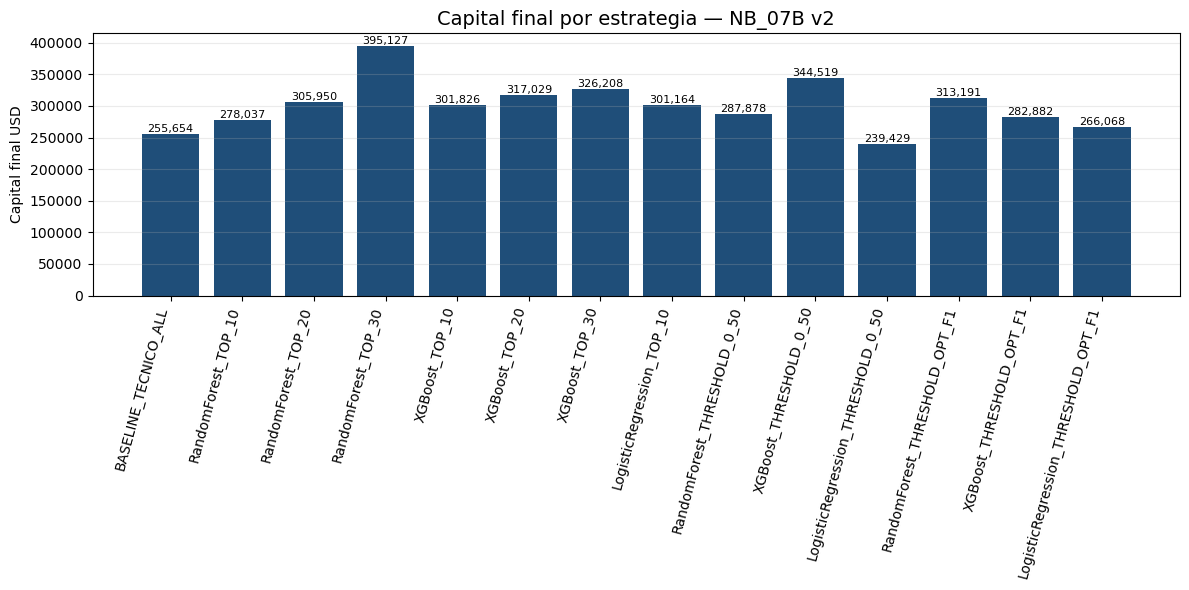

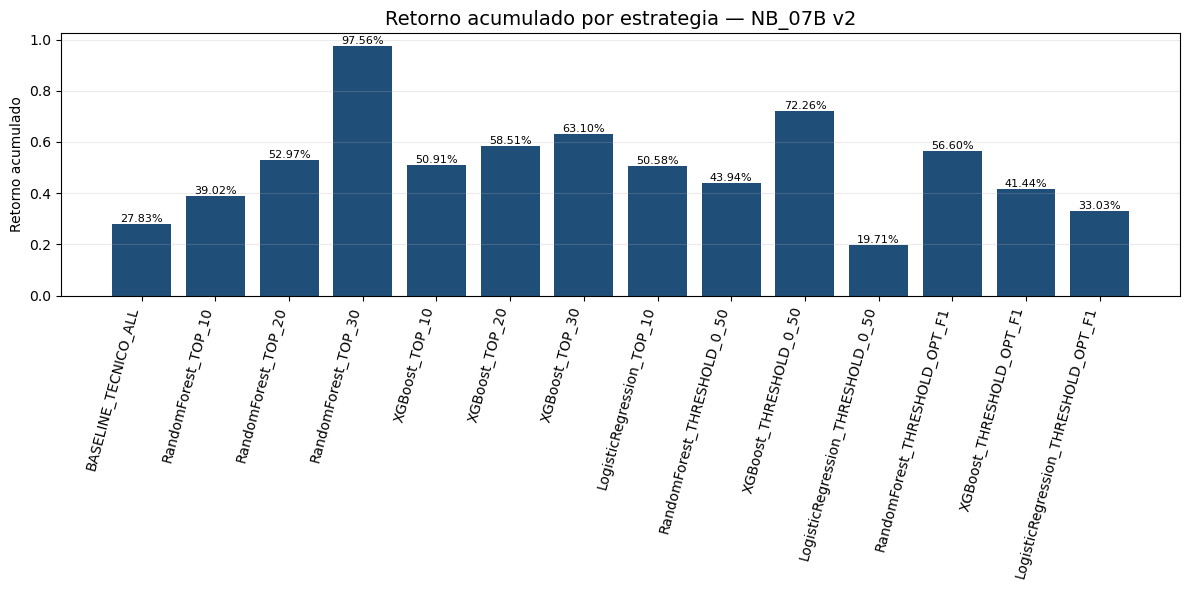

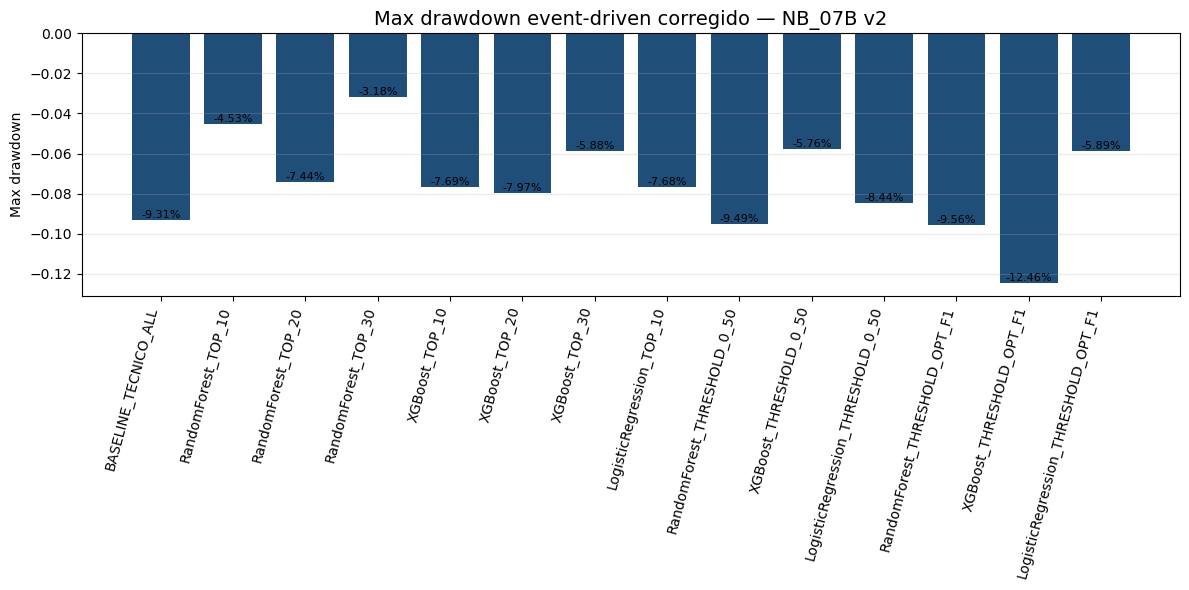

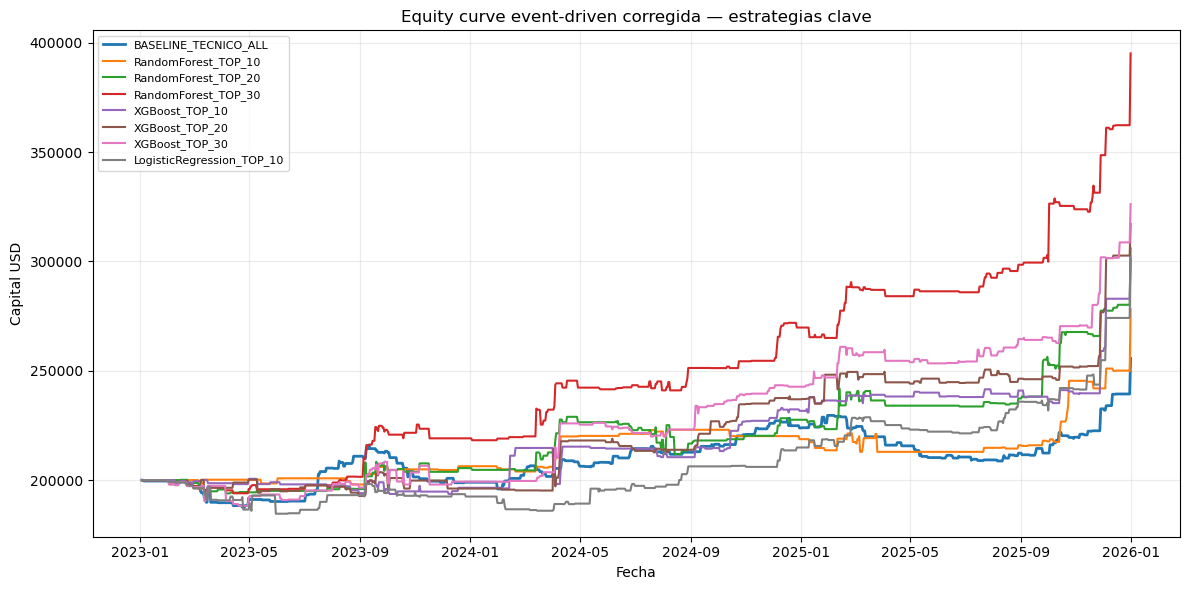

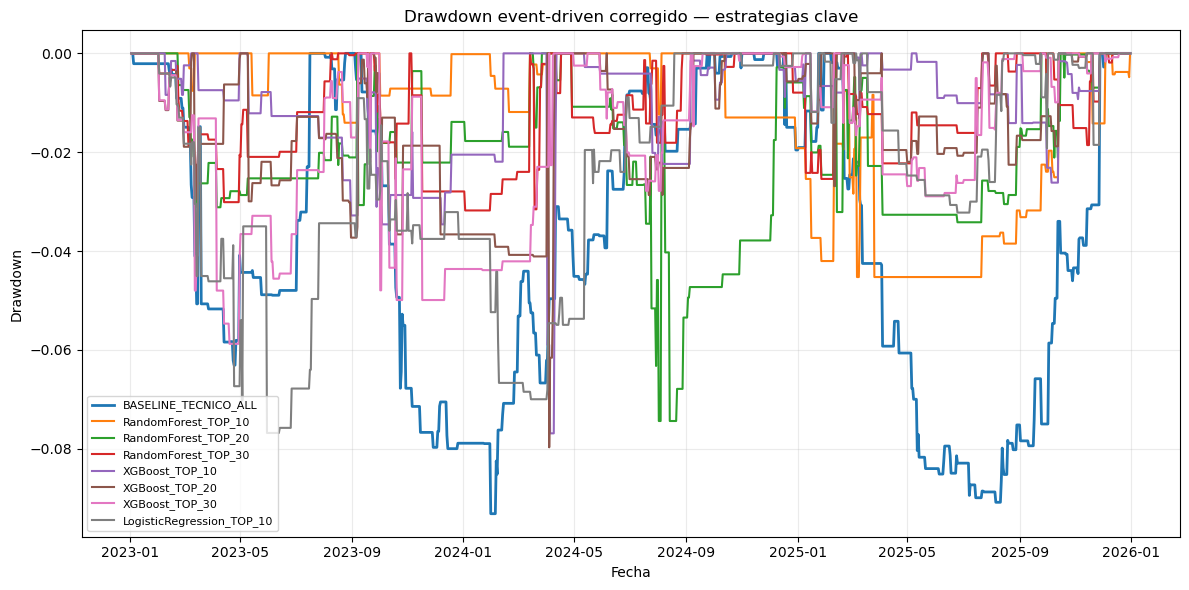

In [9]:
# ============================================================
# 8. Gráficos
# ============================================================

DARK_BLUE = "#1f4e79"

def bar_plot(df, metric, title, ylabel, filename, pct=False):
    plt.figure(figsize=(12, 6))
    bars = plt.bar(df["strategy"], df[metric], color=DARK_BLUE)
    plt.title(title, fontsize=14)
    plt.ylabel(ylabel)
    plt.xticks(rotation=75, ha="right")
    plt.grid(axis="y", alpha=0.25)
    for b in bars:
        h = b.get_height()
        if pd.notna(h):
            label = f"{h:.2%}" if pct else f"{h:,.0f}"
            plt.text(b.get_x()+b.get_width()/2, h, label, ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

bar_plot(main_comparison, "final_capital", "Capital final por estrategia — NB_07B v2", "Capital final USD", "final_capital_nb07b_v2.png", pct=False)
bar_plot(main_comparison, "total_return", "Retorno acumulado por estrategia — NB_07B v2", "Retorno acumulado", "total_return_nb07b_v2.png", pct=True)
bar_plot(main_comparison, "max_drawdown_event", "Max drawdown event-driven corregido — NB_07B v2", "Max drawdown", "max_drawdown_nb07b_v2.png", pct=True)

key_strategies = [
    "BASELINE_TECNICO_ALL",
    "RandomForest_TOP_10", "RandomForest_TOP_20", "RandomForest_TOP_30",
    "XGBoost_TOP_10", "XGBoost_TOP_20", "XGBoost_TOP_30",
    "LogisticRegression_TOP_10",
]

if not portfolio_equity.empty:
    eq = portfolio_equity.copy()
    eq["date"] = pd.to_datetime(eq["date"])

    min_date = eq["date"].min()
    max_date = eq["date"].max()
    idx = pd.date_range(min_date, max_date, freq="D")

    equity_panel = []
    plt.figure(figsize=(12, 6))
    for strategy in key_strategies:
        sub = eq[eq["strategy"] == strategy].sort_values("date")
        if sub.empty:
            continue
        s = sub.groupby("date")["equity"].last().reindex(idx).ffill().fillna(INITIAL_CAPITAL)
        equity_panel.append(pd.DataFrame({"date": idx, "strategy": strategy, "equity": s.values}))
        plt.plot(idx, s.values, label=strategy, linewidth=2 if strategy == "BASELINE_TECNICO_ALL" else 1.5)
    plt.title("Equity curve event-driven corregida — estrategias clave")
    plt.ylabel("Capital USD")
    plt.xlabel("Fecha")
    plt.grid(alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(EQUITY_DIR / "equity_curves_key_strategies_nb07b_v2.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    equity_panel = pd.concat(equity_panel, ignore_index=True)
    equity_panel.to_csv(OUTPUT_DIR / "equity_panel_daily_ffill_nb07b_v2.csv", index=False)

    dd_panel = []
    plt.figure(figsize=(12, 6))
    for strategy in key_strategies:
        sub = equity_panel[equity_panel["strategy"] == strategy].copy()
        if sub.empty:
            continue
        sub["drawdown"] = sub["equity"] / sub["equity"].cummax() - 1
        dd_panel.append(sub)
        plt.plot(sub["date"], sub["drawdown"], label=strategy, linewidth=2 if strategy == "BASELINE_TECNICO_ALL" else 1.5)
    plt.title("Drawdown event-driven corregido — estrategias clave")
    plt.ylabel("Drawdown")
    plt.xlabel("Fecha")
    plt.grid(alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(DRAWDOWN_DIR / "drawdown_curves_key_strategies_nb07b_v2.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    dd_panel = pd.concat(dd_panel, ignore_index=True)
    dd_panel.to_csv(OUTPUT_DIR / "drawdown_panel_daily_ffill_nb07b_v2.csv", index=False)

## 10. Outputs generados

In [11]:
# ============================================================
# 10. Listado de outputs
# ============================================================

for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print("-", p.relative_to(OUTPUT_DIR))

- drawdown_panel_daily_ffill_nb07b_v2.csv
- equity_panel_daily_ffill_nb07b_v2.csv
- figures/drawdowns/drawdown_curves_key_strategies_nb07b_v2.png
- figures/equity_curves/equity_curves_key_strategies_nb07b_v2.png
- figures/final_capital_nb07b_v2.png
- figures/max_drawdown_nb07b_v2.png
- figures/total_return_nb07b_v2.png
- interpretacion_preliminar_nb07b_v2.md
- portfolio_equity_events_nb07b_v2.csv
- portfolio_skipped_nb07b_v2.csv
- portfolio_trades_nb07b_v2.csv
- tables/main_portfolio_comparison_nb07b_v2.csv
- tables/portfolio_metrics_nb07b_v2.csv
- tables/yearly_portfolio_metrics_nb07b_v2.csv
